### Predicting Electric Vehicle Adoption Likehood and Forecasting Monthly Energy Consumption and Charging Costs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


#### Load Dataset

In [2]:
df = pd.read_csv("EV.csv")

#### 1. Dataset Overview

Gambaran umum dataset yang berisi 5 baris pertama dari masing-masing kolom, tipe data masing masing kolom, macam-macam kolom yang terdapat dalam dataset, deskripsi statistik dataset, jumlah baris dan kolom pada dataset.

##### 1.1 First 5 Columns

In [3]:
df.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


##### 1.2 Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

Terdapat 4 Kolom bertipe object dengan mayoritas kolom adalah numerik

##### 1.3 Jumlah Kolom dan Baris pada data

In [5]:
df.shape

(50000, 23)

Data memiliki 5.000 Baris dengan 23 Kolom

##### 1.4 Kolom yang terdapat pada data

In [6]:
df.columns

Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost'],
      dtype='object')

##### 1.5 Deskripsi Statistik data

In [7]:
df.describe()

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.000000,50000.000000
mean,44.996080,44311.869380,35.169358,228.727200,6.012842,295.169608,5.892947,7.132370,0.64976,0.215359,6.831854,5.979970,6.721914,5.288046,4.998338,6.755673,0.198200,186.740260,40.235028
std,14.110844,26109.170784,14.736042,101.147254,2.947132,130.178552,2.152186,4.801992,0.47705,0.077914,1.920217,1.955106,1.990730,2.059862,1.955411,1.945842,0.398648,88.245302,24.940343
min,21.000000,5104.000000,5.000000,25.000000,0.000000,-99.700000,1.000000,0.500000,0.00000,0.080000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,15.600000,1.400000
25%,33.000000,25617.750000,25.000000,157.700000,3.900000,205.200000,4.400000,3.000000,0.00000,0.150000,5.400000,4.600000,5.200000,3.700000,3.600000,5.300000,0.000000,124.500000,21.600000
50%,45.000000,37891.000000,35.100000,224.100000,6.000000,294.800000,5.900000,6.900000,1.00000,0.220000,7.000000,6.000000,6.700000,5.000000,5.000000,7.000000,0.000000,179.300000,35.200000
75%,57.000000,56051.250000,45.200000,294.500000,8.000000,383.000000,7.400000,10.700000,1.00000,0.280000,8.400000,7.300000,8.500000,6.800000,6.300000,8.300000,0.000000,241.500000,54.100000
max,69.000000,250000.000000,97.900000,732.300000,20.000000,862.000000,10.000000,28.500000,1.00000,0.350000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,645.900000,199.600000


Berdasarkan hasil statisik deskriptif rata rata usia partisipan dalam observasi ini adalah 44,96 tahun dengan umur paling rendah yaitu 21 tahun dan umur maksimal yaitu 69 tahun. Rata-rata pendapatan per tahun adalah 44311,86 USD dengan jarak tempuh pulang-pergi per hari yaitu  35,16 KM dan per minggu sekitar 228,72 KM. Pengeluaran untuk bensin rata rata 295,16 USD, mayoritas umur kendaraan yaitu 6 tahun. Stasiun pengisian terdekat rata rata ada pada rentang 7,13 KM. Beberapa partisipan sudah memiliki kendaraan listrik.

#### 2. Data Quality

Pada tahap ini akan dilakukan pemeriksaan terhadap missing values dan data yang mungkin terduplikat

##### 2.1 Missing Values

In [8]:
df.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

Terdapat beberapa missing values terhadap 3 kolom dengan masing-masing berjumlah 500 baris

In [24]:
df[['education_level',
    'charging_station_accessibility',
    'ev_knowledge_score']].isna().sum(axis=1).value_counts()

0    48511
1     1478
2       11
Name: count, dtype: int64

2.2 Duplicate Data

In [9]:
df.duplicated().sum()

0

Tidak terdapat duplikat nilai pada tiap kolom dalam dataset

#### 3. Exploratory Data Analysis

Tahapan Exploratory Data Analysis (EDA) dilakukan dengan membagi dataset menjadi dua kolom berdasarkan kesamaan, yaitu kolom yang berbentuk numerik dan kolom yang berbentuk kategorikal. Untuk kolom yang bersifat numerik, akan diliat distribusi, skewness, dan outlier. 

##### 3.1 Membagi dataset menjadi dua fitur yaitu numerik dan kategorikal

In [10]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

print(f"Jumlah kolom numerik yaitu sebanyak {len(num_cols)}")
print(f"Jumlah kolom kategorikal yaitu sebanyak {len(cat_cols)}")

Jumlah kolom numerik yaitu sebanyak 19
Jumlah kolom kategorikal yaitu sebanyak 4


Kolom numerik berjumlah 19 kolom dan kolom kategorikal berjumlah 4 kolom. Total keseluruhan kolom adalah 22 sama dengan gambaran awal.

##### 3.2 Distribusi,Skewness, Outlier pada Numerik

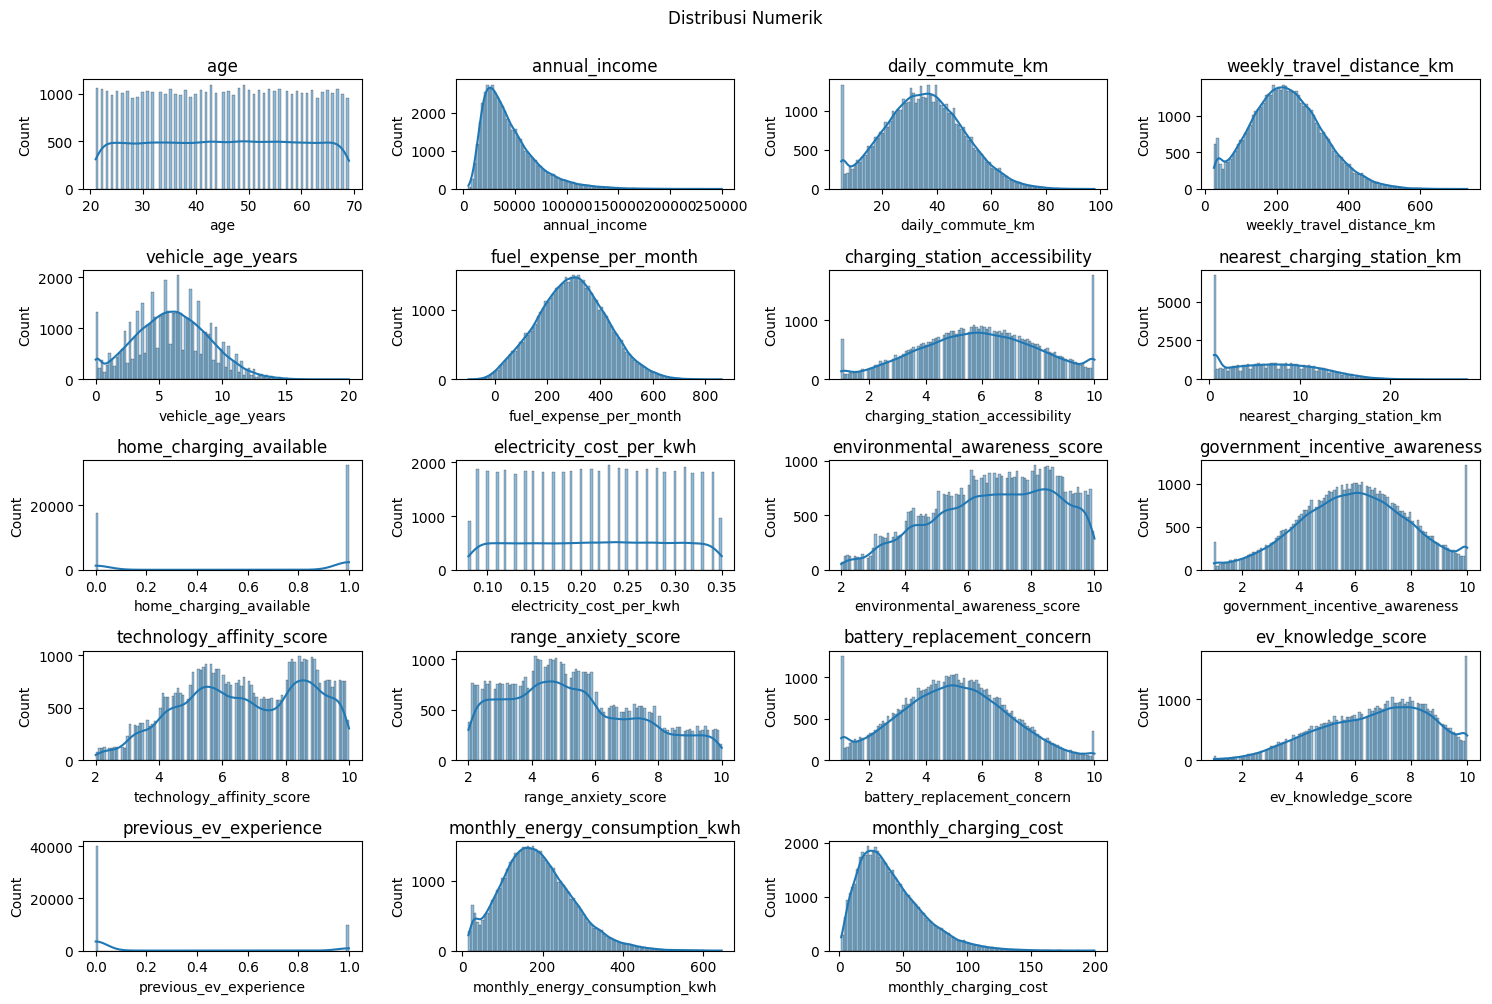

In [11]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col], kde=True, bins=100)
    plt.title(col)

plt.suptitle("Distribusi Numerik", y=1)
plt.tight_layout()
plt.show()

Berdasarkan grafik distribusi, terdapat beberapa variabel yang memiliki distribusi relatif normal seperti age dan electricity_cost_per_kwh. Beberapa distribusi kolom yang right-skewed antara lain annual_income, monthly_charging_cost, dan monthly_energy_consumption_kwh, dengan tingkat skewness masing-masing sebesar 1,65, 1,07, dan 0,54. Hal ini menunjukkan adanya ekor distribusi yang memanjang ke arah kanan, yang mengindikasikan terdapat sebagian kecil data dengan nilai yang jauh lebih tinggi dibandingkan mayoritas observasi. Sementara itu, sebagian besar variabel lainnya memiliki nilai skewness yang relatif dekat dengan 0 sehingga distribusinya cenderung simetris. Adapun home_charging_available dan previous_ev_experience memiliki skewness yang cukup tinggi, tetapi kedua variabel tersebut merupakan variabel biner sehingga nilai skewness lebih mencerminkan ketidakseimbangan proporsi antara kelas 0 dan 1 daripada kemencengan distribusi kontinu.

##### 3.3 Boxplot Numerik

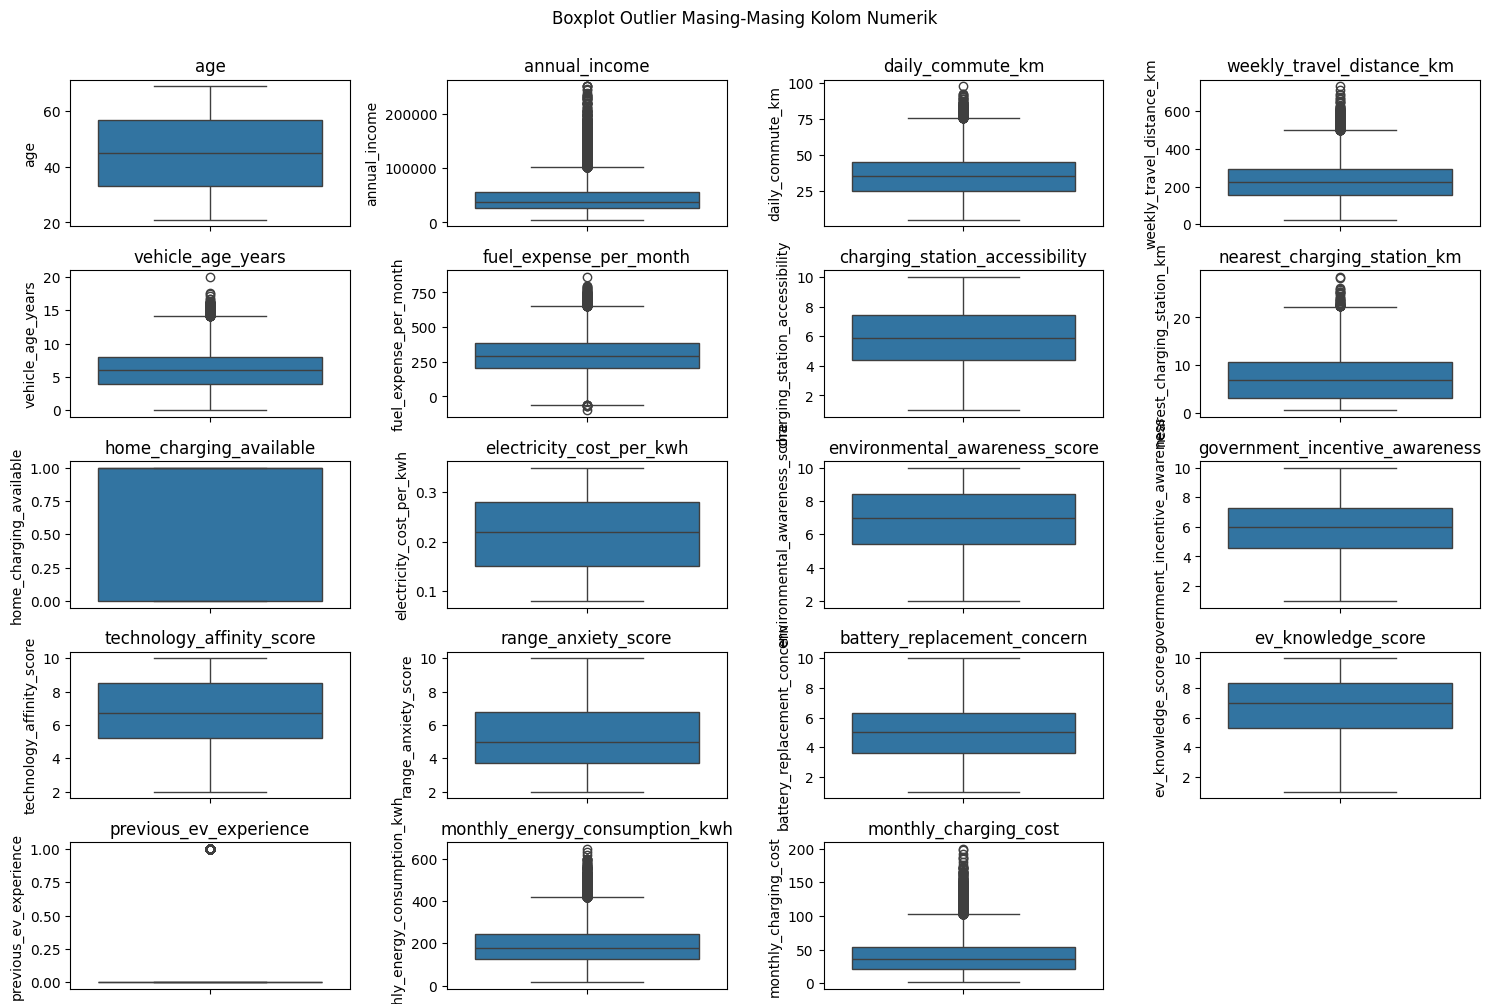

In [13]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.suptitle("Boxplot Outlier Masing-Masing Kolom Numerik", y=1)
plt.tight_layout()
plt.show()

Berdasarkan boxplot tersebut, terlihat bahwa sebagian besar variabel memiliki sebaran data yang cukup terkonsentrasi, tetapi beberapa variabel menunjukkan banyak titik di luar whisker yang mengindikasikan adanya nilai ekstrem. Pada age, tidak terlihat outlier dan data relatif tersebar normal. Annual_income menunjukkan outlier yang sangat banyak terutama pada nilai pendapatan tinggi, sehingga distribusinya cenderung right-skewed. Daily_commute_km dan weekly_travel_distance_km juga memiliki banyak outlier pada nilai tinggi, yang menunjukkan adanya sebagian responden dengan jarak perjalanan jauh. Vehicle_age_years memiliki beberapa outlier pada usia kendaraan yang tinggi, sedangkan fuel_expense_per_month memiliki outlier pada kedua sisi, baik nilai rendah maupun tinggi. Charging_station_accessibility, electricity_cost_per_kwh, environmental_awareness_score, government_incentive_awareness, technology_affinity_score, range_anxiety_score, battery_replacement_concern, dan ev_knowledge_score tidak menunjukkan outlier yang berarti. Nearest_charging_station_km memiliki beberapa outlier pada jarak yang tinggi. Monthly_energy_consumption_kwh dan monthly_charging_cost menunjukkan cukup banyak outlier pada sisi atas, yang mengindikasikan adanya responden dengan konsumsi energi dan biaya pengisian yang jauh lebih tinggi dibandingkan mayoritas data. Sementara itu, home_charging_available dan previous_ev_experience merupakan variabel biner dengan nilai 0 dan 1, sehingga titik yang terlihat pada boxplot tidak tepat dianggap sebagai outlier secara substantif; khususnya previous_ev_experience, banyaknya nilai yang terdeteksi oleh IQR kemungkinan disebabkan oleh sifat distribusi biner yang sangat tidak seimbang, bukan karena kesalahan data. Jadi, outlier yang paling perlu diperhatikan adalah annual_income, daily_commute_km, weekly_travel_distance_km, fuel_expense_per_month, nearest_charging_station_km, monthly_energy_consumption_kwh, dan monthly_charging_cost.

##### Skewness dan Outlier Per Kolom Numerik

In [23]:
skew = df[num_cols].skew()
outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()

result = pd.DataFrame({
    "Skew":skew,
    "Outliers": outliers
})

result

,Skew,Outliers
age,-0.007778,0
annual_income,1.650789,1882
daily_commute_km,0.127231,192
weekly_travel_distance_km,0.317259,377
vehicle_age_years,0.123382,170
fuel_expense_per_month,0.104406,181
charging_station_accessibility,-0.072112,0
nearest_charging_station_km,0.339479,42
home_charging_available,-0.627884,0
electricity_cost_per_kwh,-0.009990,0


##### Korelasi Fitur

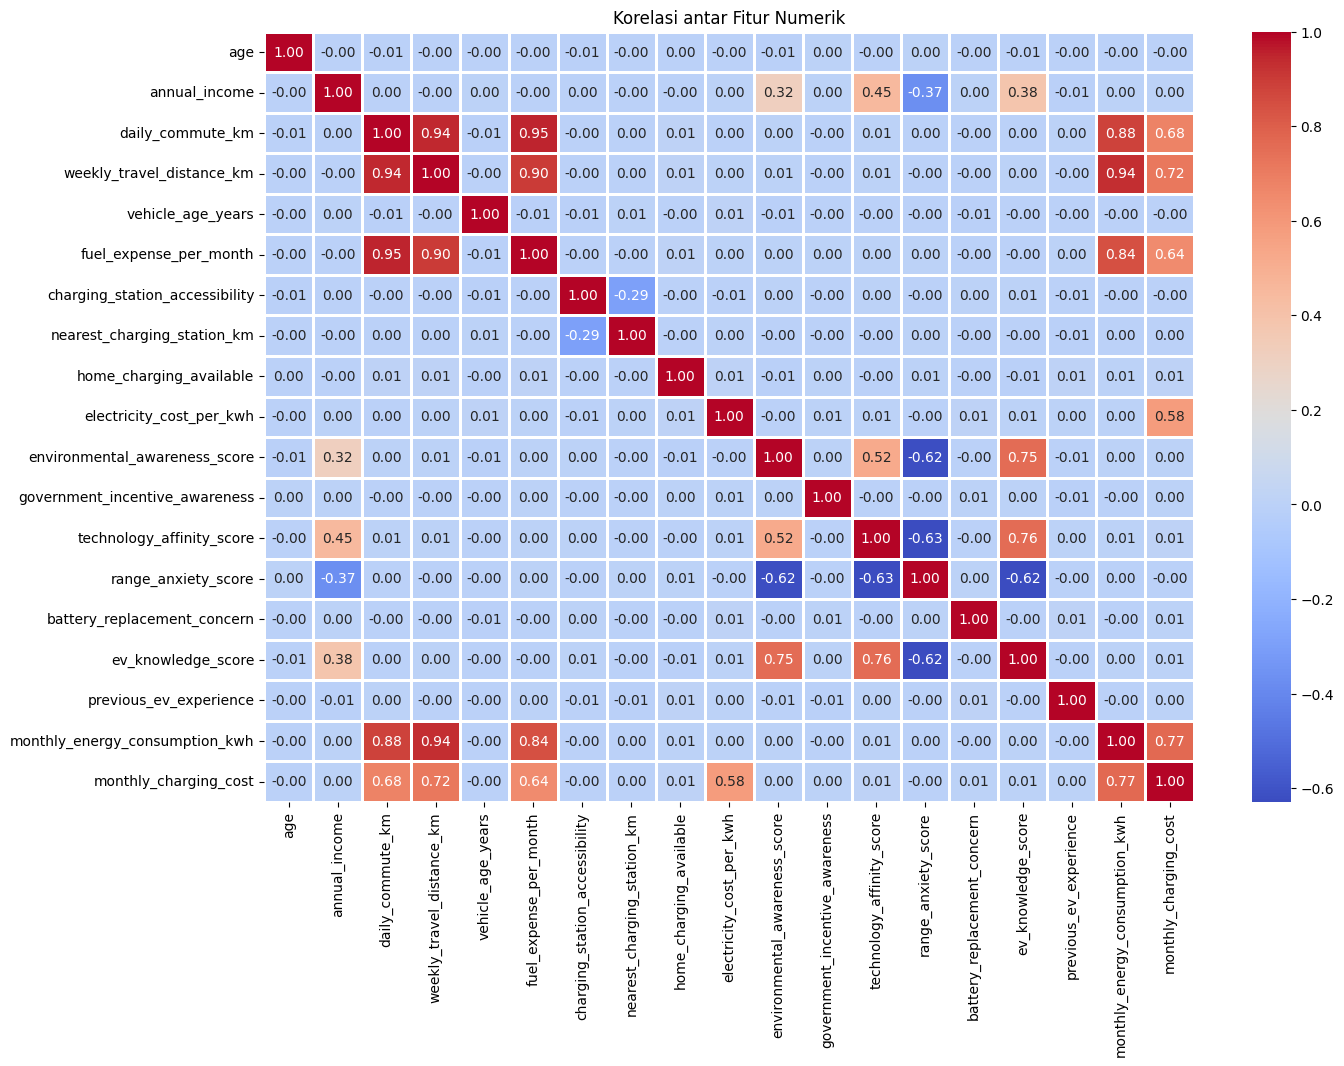

In [14]:
plt.figure(figsize=(15,10))
plt.title("Korelasi antar Fitur Numerik")
sns.heatmap(df[num_cols].corr(), linewidths=2, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

#### 4. Data Cleaning and Preprocessing

##### 4.1 Handle missing values

In [ ]:
df = df.dropna()
df.isnull().sum()

##### 4.2 Handler Outlier

##### 4.3 Handle Skewness

#### 5. Modelling and Evaluating